In [1]:
import os
import glob
import time
import json
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Dict, Optional
from pageindex import PageIndexClient

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY")

GROQ_MODEL = "openai/gpt-oss-120b"

llm = ChatGroq(api_key=GROQ_API_KEY, model=GROQ_MODEL, temperature=0)
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)

In [2]:
PDF_DIR = "./pdfs"
pdf_paths = glob.glob(os.path.join(PDF_DIR, "*.pdf"))
print(f"Found {len(pdf_paths)} PDFs:")
for p in pdf_paths:
    print(f"  {p}")

doc_records = {}  # doc_id -> {"path": ..., "filename": ..., "status": ...}

for path in pdf_paths:
    print(f"Uploading: {path}")
    result = pi_client.submit_document(path)
    doc_id = result["doc_id"]
    doc_records[doc_id] = {
        "path": path,
        "filename": os.path.basename(path),
        "status": "submitted"
    }
    print(f"  -> Document ID: {doc_id}")

Found 5 PDFs:
  ./pdfs\An Exploration of ECAPA-TDNN.pdf
  ./pdfs\DS-TTS copy.pdf
  ./pdfs\DS-TTS.pdf
  ./pdfs\Improvement Speaker Similarity for.pdf
  ./pdfs\VOCALIS_preprint.pdf
Uploading: ./pdfs\An Exploration of ECAPA-TDNN.pdf
  -> Document ID: pi-cms06ld4900b501pg2vg2ebu4
Uploading: ./pdfs\DS-TTS copy.pdf
  -> Document ID: pi-cms06lebu00b601pgoyj8yrry
Uploading: ./pdfs\DS-TTS.pdf
  -> Document ID: pi-cms06ljjo00b701pg2pp629h1
Uploading: ./pdfs\Improvement Speaker Similarity for.pdf
  -> Document ID: pi-cms06lku800b801pgq9acrozq
Uploading: ./pdfs\VOCALIS_preprint.pdf
  -> Document ID: pi-cms06lm3t00b901pg98nkm97j


In [3]:
pending = set(doc_records.keys())

while pending:
    for doc_id in list(pending):
        status_result = pi_client.get_document(doc_id)
        status = status_result.get("status")
        doc_records[doc_id]["status"] = status

        filename = doc_records[doc_id]["filename"]
        print(f"[{filename}] Status: {status}")

        if status == "completed":
            print(f"  -> Tree Index ready for {filename}")
            pending.remove(doc_id)
        elif status == "failed":
            print(f"  -> Processing FAILED for {filename}")
            pending.remove(doc_id)

    if pending:
        time.sleep(5)

completed_docs = {k: v for k, v in doc_records.items() if v["status"] == "completed"}
failed_docs = {k: v for k, v in doc_records.items() if v["status"] == "failed"}

print(f"\nCompleted: {len(completed_docs)} | Failed: {len(failed_docs)}")

[DS-TTS copy.pdf] Status: processing
[Improvement Speaker Similarity for.pdf] Status: processing
[VOCALIS_preprint.pdf] Status: processing
[An Exploration of ECAPA-TDNN.pdf] Status: completed
  -> Tree Index ready for An Exploration of ECAPA-TDNN.pdf
[DS-TTS.pdf] Status: processing
[DS-TTS copy.pdf] Status: processing
[Improvement Speaker Similarity for.pdf] Status: processing
[VOCALIS_preprint.pdf] Status: processing
[DS-TTS.pdf] Status: processing
[DS-TTS copy.pdf] Status: completed
  -> Tree Index ready for DS-TTS copy.pdf
[Improvement Speaker Similarity for.pdf] Status: completed
  -> Tree Index ready for Improvement Speaker Similarity for.pdf
[VOCALIS_preprint.pdf] Status: processing
[DS-TTS.pdf] Status: completed
  -> Tree Index ready for DS-TTS.pdf
[VOCALIS_preprint.pdf] Status: completed
  -> Tree Index ready for VOCALIS_preprint.pdf

Completed: 5 | Failed: 0


In [4]:
document_trees = {}

for doc_id, info in completed_docs.items():
    filename = info["filename"]

    print(f"\n{'=' * 60}")
    print(f"Fetching tree for: {filename}")
    print(f"Document ID: {doc_id}")

    tree_result = pi_client.get_tree(doc_id, node_summary=True)
    pageindex_tree = tree_result.get("result", [])

    # Save the tree for later use
    document_trees[doc_id] = {
        "filename": filename,
        "tree": pageindex_tree
    }

    print(f"Top level sections: {len(pageindex_tree)}")

    print("\nRaw Tree:")
    if pageindex_tree:
        print(json.dumps(pageindex_tree[0], indent=2))
    else:
        print("No tree returned.")


Fetching tree for: An Exploration of ECAPA-TDNN.pdf
Document ID: pi-cms06ld4900b501pg2vg2ebu4
Top level sections: 1

Raw Tree:
{
  "title": "An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS",
  "node_id": "0000",
  "page_index": 1,
  "prefix_summary": "This study evaluates the performance of three speaker encoders\u2014H/ASP, x-vector, and ECAPA-TDNN\u2014within a YourTTS-based zero-shot multi-speaker TTS system using Czech speech data. Through subjective listening tests and objective cosine distance measurements, the researchers found that the original H/ASP encoder consistently outperformed the others, indicating that popular speaker recognition embeddings like ECAPA-TDNN do not necessarily enhance speaker similarity in TTS and highlighting the necessity of empirical validation when repurposing such models.",
  "text": "# An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS\n\nMarie Kune\u016

In [5]:
def print_tree(nodes, indent=0):
    """Recursively print tree titles for a visual overview"""
    for node in nodes:
        prefix = " " * indent + ("|_ " if indent > 0 else "")
        page = node.get("page_index", "?")
        print(f"{prefix}[{node['node_id']}] {node['title']} (p.{page})")

        if node.get("nodes"):
            print_tree(node["nodes"], indent + 1)


# Print the tree for every completed document
for doc_id, data in document_trees.items():
    print("\n" + "=" * 70)
    print(f"Document: {data['filename']}")
    print(f"Document ID: {doc_id}")
    print("=" * 70)

    print_tree(data["tree"])


Document: An Exploration of ECAPA-TDNN.pdf
Document ID: pi-cms06ld4900b501pg2vg2ebu4
[0000] An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS (p.1)
 |_ [0001] 1 Introduction (p.1)
 |_ [0002] 2 TTS system (p.3)
  |_ [0003] 2.1 Training Data (p.3)
  |_ [0004] 2.2 Target speaker data (p.4)
  |_ [0005] 2.3 Speaker encoders (p.4)
 |_ [0006] 3 Listening test (p.5)
 |_ [0007] 4 Objective evaluation (p.7)
 |_ [0008] 5 Conclusions (p.10)
 |_ [0009] References (p.10)

Document: DS-TTS copy.pdf
Document ID: pi-cms06lebu00b601pgoyj8yrry
[0000] DS-TTS: Zero-Shot Speaker Style Adaptation from Voice Clips via Dynamic Dual-Style Feature Modulation (p.1)
[0001] I. INTRODUCTION (p.1)
[0002] II. RELATED WORK (p.2)
[0003] III. DS-TTS (p.3)
 |_ [0004] A. Problem Formulation (p.3)
 |_ [0005] B. Model Architecture Overview (p.3)
 |_ [0006] C. Dual-Style Encoding Network (p.3)
 |_ [0007] D. Dynamic Generator Network (p.4)
[0008] IV. EXPERIMENT SETUP (p.6)
[0009]

In [6]:
def flatten_tree(nodes: List[Dict], doc_id: str, filename: str, parent_title: str = None) -> List[Dict]:
    """
    Recursively flattens PageIndex's nested tree into a flat list of
    citation-ready section records.
    """
    flat_nodes = []

    for node in nodes:
        summary = node.get("summary") or node.get("prefix_summary") or ""

        title = node["title"]
        full_title = f"{parent_title} > {title}" if parent_title else title

        flat_nodes.append({
            "doc_id": doc_id,
            "filename": filename,
            "node_id": node["node_id"],
            "section_title": full_title,
            "summary": summary,
            "page_index": node.get("page_index"),
            "text": node.get("text", ""),
        })

        children = node.get("nodes", [])
        if children:
            flat_nodes.extend(
                flatten_tree(children, doc_id, filename, parent_title=full_title)
            )

    return flat_nodes


document_index = []

for doc_id, data in document_trees.items():
    filename = data["filename"]
    flat_nodes = flatten_tree(data["tree"], doc_id, filename)
    document_index.extend(flat_nodes)

print(f"Total indexed sections across all docs: {len(document_index)}")
for node in document_index[:5]:
    print(f"[{node['doc_id']}] {node['section_title']} (p.{node['page_index']}) — {node['summary'][:80]}...")

Total indexed sections across all docs: 82
[pi-cms06ld4900b501pg2vg2ebu4] An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS (p.1) — This study evaluates the performance of three speaker encoders—H/ASP, x-vector, ...
[pi-cms06ld4900b501pg2vg2ebu4] An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS > 1 Introduction (p.1) — This text introduces zero-shot multi-speaker TTS and the critical role of speake...
[pi-cms06ld4900b501pg2vg2ebu4] An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS > 2 TTS system (p.3) — This section details the use of the YourTTS system, a VITS-based model utilizing...
[pi-cms06ld4900b501pg2vg2ebu4] An Exploration of ECAPA-TDNN and x-vector Speaker Representations in Zero-shot Multi-speaker TTS > 2 TTS system > 2.1 Training Data (p.3) — The text details the 'SPT-MGW' Czech speech dataset used for TTS model training,...
[pi-cms06l

In [ ]:
# def get_text_content(response) -> str:
#     """
#     Handles both plain string responses and list-of-content-blocks responses
#     (some models/providers return content as a list of blocks instead of a plain string).
#     """
#     content = response.content

#     if isinstance(content, str):
#         return content

#     if isinstance(content, list):
#         text_parts = []
#         for block in content:
#             if isinstance(block, dict):
#                 if block.get("type") == "text":
#                     text_parts.append(block.get("text", ""))
#             elif isinstance(block, str):
#                 text_parts.append(block)
#         return "".join(text_parts)

#     return str(content)

In [ ]:
# def summarize_single_paper(doc_id: str, data: dict) -> dict:
#     """
#     Extracts key facts from ONE paper at a time — keeps each prompt small
#     enough to stay well under Groq's TPM limit, regardless of total paper count.
#     """
#     filename = data["filename"]
#     sections = flatten_tree(data["tree"], doc_id, filename)
#     section_summaries = "\n".join(
#         f"  - {s['section_title']}: {s['summary'][:150]}" for s in sections[:12]
#     )

#     prompt = f"""Extract key facts from this paper's sections:
# [{filename}]
# {section_summaries}

# Reply ONLY in this JSON format, no other text:
# {{"filename": "{filename}", "method": "...", "technique": "...", "evaluation": "...", "finding": "..."}}"""

#     response = llm.invoke([HumanMessage(content=prompt)])
#     raw_text = get_text_content(response)
#     return json.loads(raw_text)

In [ ]:
# def determine_themes(paper_facts: list) -> list:
#     """
#     Second stage: given already-condensed per-paper facts (much smaller than
#     full summaries), determine thematic groupings in one lightweight call.
#     """
#     facts_text = json.dumps(paper_facts, indent=None)

#     prompt = f"""Based on these extracted paper facts, identify 2-4 thematic groups
# that organize these papers (a paper can belong to multiple themes):

# {facts_text}

# Reply ONLY in this JSON format, no other text:
# {{
#     "themes": [
#         {{"name": "...", "papers": ["filename1.pdf", "filename2.pdf"], "description": "..."}}
#     ]
# }}"""

#     response = llm.invoke([HumanMessage(content=prompt)])
#     raw_text = get_text_content(response)
#     parsed = json.loads(raw_text)
#     return parsed["themes"]

In [43]:
def build_shared_context_node(state: dict) -> dict:
    papers_overview = []
    for doc_id, data in state["document_trees"].items():
        filename = data["filename"]
        sections = flatten_tree(data["tree"], doc_id, filename)
        # Truncate each summary, and cap number of sections per paper to control size
        section_summaries = "\n".join(
            f"  - {s['section_title']}: {s['summary'][:150]}"
            for s in sections[:15]  # cap sections per paper if a doc has many
        )
        papers_overview.append(f"[{filename}]\n{section_summaries}")

    all_papers_text = "\n\n".join(papers_overview)

    prompt = f"""You are analyzing {len(state['document_trees'])} research papers to prepare
for writing a literature review. Based on their section summaries below, extract:

1. THEMES: 2-4 thematic groups that organize these papers (a paper can belong to
   multiple themes). For each theme, list which papers belong to it and why.
2. PER-PAPER KEY FACTS: for each paper, extract its core method/approach, key technique,
   evaluation approach, and main finding/conclusion, each in 1-2 sentences.

Papers:
{all_papers_text}

Reply ONLY in this JSON format, no other text:
{{
    "themes": [
        {{"name": "...", "papers": ["filename1.pdf", "filename2.pdf"], "description": "..."}}
    ],
    "paper_facts": [
        {{"filename": "...", "method": "...", "technique": "...", "evaluation": "...", "finding": "..."}}
    ]
}}"""

    response = llm.invoke([HumanMessage(content=prompt)])
    raw_text = get_text_content(response)
    state["shared_context"] = json.loads(raw_text)
    return state

In [44]:
def write_overview_node(state: dict) -> dict:
    ctx = state["shared_context"]
    prompt = f"""Write a concise Overview (roughly 100-150 words) for a literature review
covering {len(state['document_trees'])} papers. Themes identified: {json.dumps(ctx['themes'])}.

Describe the collective scope and what this review aims to synthesize. Do not list
papers individually by name and content — describe the overall landscape and focus areas."""

    response = llm.invoke([HumanMessage(content=prompt)])
    state["section_overview"] = get_text_content(response)
    return state

In [45]:
def write_thematic_grouping_node(state: dict) -> dict:
    ctx = state["shared_context"]
    prompt = f"""Write the "Thematic Grouping" section of a literature review (roughly 200-250 words).
Themes and paper assignments: {json.dumps(ctx['themes'])}

For each theme, write a short paragraph synthesizing what the papers in that theme
collectively contribute. Reference papers using (filename.pdf) format. Explain how
papers within a theme relate to each other, not just what each one does individually."""

    response = llm.invoke([HumanMessage(content=prompt)])
    state["section_thematic_grouping"] = get_text_content(response)
    return state

In [46]:
def write_methodology_comparison_node(state: dict) -> dict:
    ctx = state["shared_context"]
    prompt = f"""Write the "Methodology Comparison" section of a literature review.
Per-paper facts: {json.dumps(ctx['paper_facts'])}

Present this as a markdown table with columns: Paper | Method/Approach | Key Technique | Evaluation Approach.
Use (filename.pdf) to identify each paper in the Paper column.
If any paper's methodology doesn't fit cleanly into the table, add 1-2 sentences of
prose below the table to clarify. Keep the table concise — one row per paper."""

    response = llm.invoke([HumanMessage(content=prompt)])
    state["section_methodology"] = get_text_content(response)
    return state

In [47]:
def write_key_findings_node(state: dict) -> dict:
    ctx = state["shared_context"]
    prompt = f"""Write the "Key Findings Comparison" section of a literature review
(roughly 200-250 words). Per-paper facts: {json.dumps(ctx['paper_facts'])}

Explicitly identify where papers AGREE, DISAGREE, or COMPLEMENT each other's findings.
Reference papers using (filename.pdf) format. This is the most important section —
genuine synthesis and comparison, not parallel summaries of each paper in isolation."""

    response = llm.invoke([HumanMessage(content=prompt)])
    state["section_key_findings"] = get_text_content(response)
    return state

In [48]:
def write_gaps_node(state: dict) -> dict:
    ctx = state["shared_context"]
    prompt = f"""Based on this literature review's findings so far:

Themes: {json.dumps(ctx['themes'])}
Key Findings section: {state['section_key_findings']}

Write a "Gaps & Future Directions" section (roughly 150-200 words) — what do these
papers collectively NOT address? What open questions or limitations span across the
set? Reference papers using (filename.pdf) format where relevant."""

    response = llm.invoke([HumanMessage(content=prompt)])
    state["section_gaps"] = get_text_content(response)
    return state

In [49]:
def write_references_node(state: dict) -> dict:
    refs = []
    for doc_id, data in state["document_trees"].items():
        refs.append(f"- {data['filename']}")
    state["section_references"] = "\n".join(refs)
    return state

In [50]:
def assemble_review_node(state: dict) -> dict:
    state["final_review"] = f"""# Literature Review

## Overview
{state['section_overview']}

## Thematic Grouping
{state['section_thematic_grouping']}

## Methodology Comparison
{state['section_methodology']}

## Key Findings Comparison
{state['section_key_findings']}

## Gaps & Future Directions
{state['section_gaps']}

## References
{state['section_references']}
"""
    return state

In [51]:
from typing import TypedDict, Dict

class SynthesizeState(TypedDict):
    document_trees: dict
    shared_context: dict
    section_overview: str
    section_thematic_grouping: str
    section_methodology: str
    section_key_findings: str
    section_gaps: str
    section_references: str
    final_review: str

In [52]:
graph = StateGraph(SynthesizeState)
graph.add_node("build_shared_context", build_shared_context_node)
graph.add_node("write_overview", write_overview_node)
graph.add_node("write_thematic_grouping", write_thematic_grouping_node)
graph.add_node("write_methodology", write_methodology_comparison_node)
graph.add_node("write_key_findings", write_key_findings_node)
graph.add_node("write_gaps", write_gaps_node)
graph.add_node("write_references", write_references_node)
graph.add_node("assemble", assemble_review_node)

graph.set_entry_point("build_shared_context")
graph.add_edge("build_shared_context", "write_overview")
graph.add_edge("write_overview", "write_thematic_grouping")
graph.add_edge("write_thematic_grouping", "write_methodology")
graph.add_edge("write_methodology", "write_key_findings")
graph.add_edge("write_key_findings", "write_gaps")
graph.add_edge("write_gaps", "write_references")
graph.add_edge("write_references", "assemble")
graph.add_edge("assemble", END)

synthesize_graph = graph.compile()

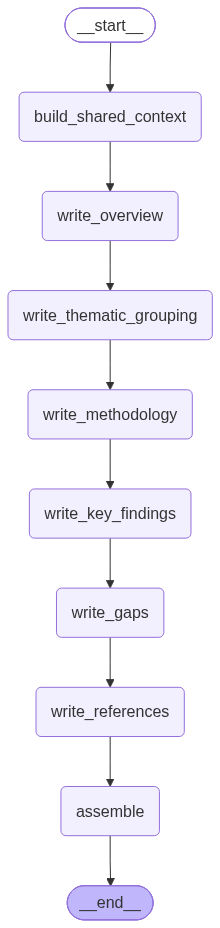

In [53]:
from IPython.display import display, Image

Image(synthesize_graph.get_graph().draw_mermaid_png())

In [56]:
# New cell — place after document_trees is built, before generating the review
document_trees_deduped = {
    doc_id: data for doc_id, data in document_trees.items()
    if data["filename"] != "DS-TTS copy.pdf"
}

print(f"Original: {len(document_trees)} docs, Deduped: {len(document_trees_deduped)} docs")

Original: 5 docs, Deduped: 4 docs


In [54]:
def generate_literature_review(document_trees: dict) -> dict:
    initial_state: SynthesizeState = {
        "document_trees": document_trees,
        "shared_context": {},
        "section_overview": "",
        "section_thematic_grouping": "",
        "section_methodology": "",
        "section_key_findings": "",
        "section_gaps": "",
        "section_references": "",
        "final_review": "",
    }
    result = synthesize_graph.invoke(initial_state)
    return {
        "review_text": result["final_review"],
        "shared_context": result["shared_context"],
    }

In [57]:
import time
t0 = time.time()
response = generate_literature_review(document_trees_deduped)  # <-- changed from document_trees
print(f"Time: {time.time() - t0:.1f}s")
print(response["review_text"])

Time: 30.7s
# Literature Review

## Overview
This review surveys recent advances in zero‑shot speech synthesis, focusing on how modern systems generate unseen speakers or styles without speaker‑specific fine‑tuning. It examines three complementary strands of research: (1) zero‑shot adaptation pipelines that combine robust speaker encoders with flexible conditioning mechanisms, enabling any‑to‑any voice conversion—including whispered or expressive speech; (2) the development and refinement of speaker‑embedding representations, where newer architectures such as ECAPA‑TDNN are benchmarked against traditional x‑vectors and further enhanced by residual adapters that narrow the synthetic‑natural embedding gap; and (3) architectural innovations that permit dynamic, inference‑time adaptation, ranging from dual‑style encoding networks to lightweight residual MLP adapters stacked on frozen encoders. By integrating these themes, the review aims to synthesize a unified picture of how embedding qua

In [65]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch
import re


def sanitize_text(text: str) -> str:
    """Replaces known problematic unicode characters, then catches any
    remaining character the PDF font can't render at all."""
    replacements = {
        '\u2011': '-', '\u2010': '-', '\u2012': '-',
        '\u2013': '-', '\u2014': '--',
        '\u2018': "'", '\u2019': "'",
        '\u201c': '"', '\u201d': '"',
        '\u2026': '...',
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)

    # Catch-all: replace any character not encodable in latin-1
    # (ReportLab's default fonts use latin-1/WinAnsi encoding)
    cleaned_chars = []
    for ch in text:
        try:
            ch.encode('latin-1')
            cleaned_chars.append(ch)
        except UnicodeEncodeError:
            cleaned_chars.append('-')
    return ''.join(cleaned_chars)


def convert_inline_markdown(text: str) -> str:
    """Converts markdown bold/italic to reportlab XML tags. Order matters —
    bold (**) must be handled before italic (*) to avoid double-processing."""
    text = sanitize_text(text)
    text = re.sub(r'\*\*(.+?)\*\*', r'<b>\1</b>', text)
    text = re.sub(r'\*(.+?)\*', r'<i>\1</i>', text)
    return text


def strip_duplicate_heading(paragraph_text: str, heading: str) -> str:
    """If the paragraph's first line just repeats the section heading
    (bold or plain), strip it — the heading is already rendered separately."""
    cleaned = paragraph_text.strip()
    heading_variants = [heading, f"**{heading}**"]
    for variant in heading_variants:
        if cleaned.startswith(variant):
            cleaned = cleaned[len(variant):].strip()
    return cleaned


def parse_markdown_table(table_lines: list) -> list:
    rows = []
    for line in table_lines:
        line = line.strip()
        if not line or set(line) <= {"|", "-", " ", ":"}:
            continue
        cells = [c.strip() for c in line.strip("|").split("|")]
        rows.append(cells)
    return rows


def export_review_to_pdf(review_text: str, output_path: str, title: str = "Literature Review"):
    doc = SimpleDocTemplate(output_path, pagesize=letter,
                             topMargin=0.75*inch, bottomMargin=0.75*inch)
    styles = getSampleStyleSheet()

    heading_style = ParagraphStyle(
        'CustomHeading', parent=styles['Heading2'],
        textColor=colors.HexColor('#371e77'), spaceBefore=16, spaceAfter=8
    )
    title_style = ParagraphStyle(
        'CustomTitle', parent=styles['Title'],
        textColor=colors.HexColor('#1C033C')
    )
    body_style = ParagraphStyle(
        'CustomBody', parent=styles['Normal'], spaceAfter=8, leading=15
    )
    cell_style = ParagraphStyle(
        'CellText', parent=styles['Normal'], fontSize=8, leading=10
    )
    bullet_style = ParagraphStyle(
        'Bullet', parent=styles['Normal'], leftIndent=14, spaceAfter=4
    )

    story = [Paragraph(sanitize_text(title), title_style), Spacer(1, 12)]

    lines = review_text.split("\n")
    i = 0
    paragraph_buffer = []
    current_heading = ""
    just_added_heading = False  # NEW: tracks consecutive duplicate headings

    def flush_paragraph():
        nonlocal just_added_heading
        if paragraph_buffer:
            text = " ".join(paragraph_buffer).strip()
            text = strip_duplicate_heading(text, current_heading)
            if text:
                story.append(Paragraph(convert_inline_markdown(text), body_style))
                just_added_heading = False
            paragraph_buffer.clear()

    while i < len(lines):
        line = lines[i]

        if line.startswith("## "):
            new_heading = line.replace("## ", "").strip()
            if new_heading == current_heading and just_added_heading:
                # Same heading appeared twice in a row — skip the duplicate
                i += 1
                continue
            flush_paragraph()
            current_heading = new_heading
            story.append(Paragraph(sanitize_text(current_heading), heading_style))
            just_added_heading = True
        elif line.startswith("# "):
            i += 1
            continue
        elif line.strip().startswith("- "):
            flush_paragraph()
            bullet_text = convert_inline_markdown(line.strip()[2:])
            story.append(Paragraph(f"• {bullet_text}", bullet_style))
            just_added_heading = False
        elif line.strip().startswith("|"):
            flush_paragraph()
            table_lines = []
            while i < len(lines) and lines[i].strip().startswith("|"):
                table_lines.append(lines[i])
                i += 1
            raw_rows = parse_markdown_table(table_lines)
            if raw_rows:
                wrapped_rows = [
                    [Paragraph(convert_inline_markdown(cell), cell_style) for cell in row]
                    for row in raw_rows
                ]
                num_cols = len(raw_rows[0])
                col_width = (letter[0] - 1.5*inch) / num_cols
                t = Table(wrapped_rows, colWidths=[col_width] * num_cols, hAlign='LEFT')
                t.setStyle(TableStyle([
                    ('BACKGROUND', (0, 0), (-1, 0), colors.HexColor('#f0f0f0')),
                    ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
                    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
                    ('LEFTPADDING', (0, 0), (-1, -1), 4),
                    ('RIGHTPADDING', (0, 0), (-1, -1), 4),
                ]))
                story.append(t)
                story.append(Spacer(1, 10))
            just_added_heading = False
            continue
        elif line.strip() == "":
            flush_paragraph()
        else:
            paragraph_buffer.append(line)

        i += 1

    flush_paragraph()
    doc.build(story)
    return output_path

In [66]:
def get_copyable_text(review_text: str) -> str:
    """Returns the review as-is, ready for a copyable text widget in Streamlit."""
    return review_text

In [67]:
pdf_path = export_review_to_pdf(response["review_text"], "literature_review.pdf")
print(f"PDF saved to: {pdf_path}")

PDF saved to: literature_review.pdf
